In [1]:
import torch

In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

from model_v2_compatible import SeqNN

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
model0 = SeqNN()
# model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt", map_location=device))
model0.load_state_dict(torch.load("/scratch1/smaruj/Akita_pytorch_models/finetuned/mouse_models/Vian2018_Bcells/models/model0_Vian2018_Bcells_from_scratch_LR0.01.pth", map_location=device))
model0.eval()

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [5]:
model1 = SeqNN()
# model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt", map_location=device))
model1.load_state_dict(torch.load("/scratch1/smaruj/Akita_pytorch_models/finetuned/mouse_models/Vian2018_Bcells/models/model1_Bcells_from_scratch_optuna.pth", map_location=device))
model1.eval()

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [ ]:
model2 = SeqNN()
# model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt", map_location=device))
model2.load_state_dict(torch.load("/scratch1/smaruj/Akita_pytorch_models/finetuned/mouse_models/Monahan2019_ORC/models/Akita_v2_mouse_Monahan2019_ORC_model2_LR0.005_finetuned.pth", map_location=device))
model2.eval()

In [ ]:
model3 = SeqNN()
# model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt", map_location=device))
model3.load_state_dict(torch.load("/scratch1/smaruj/Akita_pytorch_models/finetuned/mouse_models/Monahan2019_ORC/models/Akita_v2_mouse_Monahan2019_ORC_model3_LR0.005_finetuned.pth", map_location=device))
model3.eval()

In [6]:
import pandas as pd

In [7]:
FOLD = 0

In [8]:
df = pd.read_csv(f"/scratch1/smaruj/genomic_flat_regions/flat_regions_chrom_states_tsv/fold{FOLD}_selected_genomic_windows_centered_chrom_states.tsv", sep="\t")

In [9]:
# fountain_mask_path = "/scratch1/smaruj/generate_genomic_fountain/fountain_indices.pt"
fountain_mask_path = "/scratch1/smaruj/generate_genomic_fountain/fountain_flat_indices.pt"

In [10]:
import sys
sys.path.insert(0, "/home1/smaruj/ledidi")
from ledidi import Ledidi

In [11]:
bin_size = 2048
cropping_applied = 64
padding_bins = 2
padding = padding_bins * bin_size

# 256 +- 25 (50 bins in the center)
slice_0_bins = [i for i in range(231, 281)]
slice_0_start = (min(slice_0_bins) + cropping_applied - padding_bins) * bin_size
slice_0_end = (max(slice_0_bins) + 1 + cropping_applied + padding_bins) * bin_size

In [12]:
for row in df[1:2].itertuples(index=False):
    chrom, pred_start, pred_end = row.chrom, row.centered_start, row.centered_end
    
    print(f"Fountain generation for genome location: {chrom}:{pred_start}-{pred_end}")
    
    X = torch.load(f"/scratch1/smaruj/generate_genomic_boundary/ohe_X/fold{FOLD}/{chrom}_{pred_start}_{pred_end}_X.pt", weights_only=True, map_location=device)
    target = torch.load(f"/scratch1/smaruj/generate_genomic_fountain/Bcell_targets_fold0/{chrom}_{pred_start}_{pred_end}_target.pt", weights_only=True, map_location=device)
    tower_output_path = f"/scratch1/smaruj/generate_genomic_fountain/Bcell_tower_out_fold0/{chrom}_{pred_start}_{pred_end}_tower_out.pt"
    
    wrapper = Ledidi(model0, 
                 input_loss=torch.nn.L1Loss(reduction='sum'), 
                 output_loss=torch.nn.L1Loss(reduction='sum'),
                 batch_size=1,
                 max_iter=2000,
                 early_stopping_iter=2000,
                 return_history=False,
                 verbose=True,
                 bin_size=2048,
                 input_mask_slices_0=[i for i in range(231, 281)], # mid-bin
                 cropping_applied=64,
                 output_mask_path=fountain_mask_path,
                 use_semifreddo=True,
                 semifreddo_temp_output_path=tower_output_path,
                 punish_ctcf=False,
                 ctcf_meme_path=None
                 ).cuda()
    
    slice_0_torch = X[:, :, slice_0_start:slice_0_end]
    
    x_bar_slice_0, last_update, _, _, _ = wrapper.fit_transform(X=slice_0_torch, y_bar=target)
    
    # torch.save(x_bar_slice_0[:,:,padding:-padding], f"/scratch1/smaruj/genomic_insertion_loci/results/{chrom}_{pred_start}_{pred_end}_slice.pt")
    

Fountain generation for genome location: chr11:65677312-66988032
Model in train mode: False
Gradients enabled for weights - slice 0: True
Weights shape - slice 0: torch.Size([1, 4, 102400])
Local loss applied.
iter=I	input_loss=0.0	output_loss=6.508e+04	total_loss=6.508e+04	time=0.0
iter=100	input_loss=1.308e+04	output_loss=5.873e+03	total_loss=7.181e+03	time=7.784
iter=200	input_loss=1.061e+04	output_loss=4.545e+03	total_loss=5.606e+03	time=7.68
iter=300	input_loss=1.167e+04	output_loss=3.868e+03	total_loss=5.035e+03	time=7.676
iter=400	input_loss=1.32e+04	output_loss=5.987e+03	total_loss=7.307e+03	time=7.682
iter=500	input_loss=1.458e+04	output_loss=4e+03	total_loss=5.458e+03	time=7.683
iter=600	input_loss=1.589e+04	output_loss=3.386e+03	total_loss=4.975e+03	time=7.684
iter=700	input_loss=1.668e+04	output_loss=3.701e+03	total_loss=5.369e+03	time=7.686
iter=800	input_loss=1.758e+04	output_loss=4.526e+03	total_loss=6.285e+03	time=7.675
iter=900	input_loss=1.799e+04	output_loss=5.439e+0

In [14]:
X = torch.load(f"/scratch1/smaruj/generate_genomic_boundary/ohe_X/fold0/chr11_65677312_66988032_X.pt", weights_only=True, map_location=device)

In [15]:
with torch.no_grad():
    og_pred_model0 = model0(X)

In [16]:
X_new = X.clone()

In [17]:
slice = [i for i in range(231, 281)]
cropping = 64
bin_size = 2048

edit_start = (min(slice) + cropping) * bin_size
edit_end = (max(slice) + 1 + cropping) * bin_size

In [18]:
X_new[:, :, edit_start:edit_end] = x_bar_slice_0[:, :, 4096:-4096]

In [19]:
target_len = 1048576
current_len = X_new.shape[-1]

In [ ]:
import numpy as np

In [ ]:
# Compute how many bases to cut from each side
cut = (current_len - target_len) // 2

# Crop symmetrically
X_cropped = X_new[:, :, cut:cut + target_len]
print(X_cropped.shape)  # should print: torch.Size([1, 4, 1048576])

# Convert to numpy and save
X_np = X_cropped.squeeze(0).cpu().detach().numpy()  # shape (4, 1048576)
np.save("/scratch1/smaruj/generate_genomic_fountain/X_ex0_cropped.npy", X_np)

In [20]:
with torch.no_grad():
    ed_pred_model0 = model0(X_new)
    ed_pred_model1 = model1(X_new)
    # ed_pred_model2 = model2(X_new)
    # ed_pred_model3 = model3(X_new)

In [21]:
# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)

    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [22]:
import matplotlib.pyplot as plt

In [23]:
import numpy as np

<Figure size 800x800 with 0 Axes>

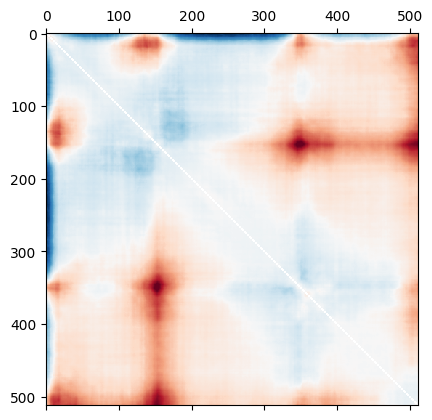

In [24]:
plt.figure(figsize=(8, 8))
matrix = from_upper_triu(og_pred_model0, matrix_len=512, num_diags=2)
plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
# plt.colorbar()
# plt.savefig("fountain_difference.svg", format='svg')
plt.show()

<Figure size 800x800 with 0 Axes>

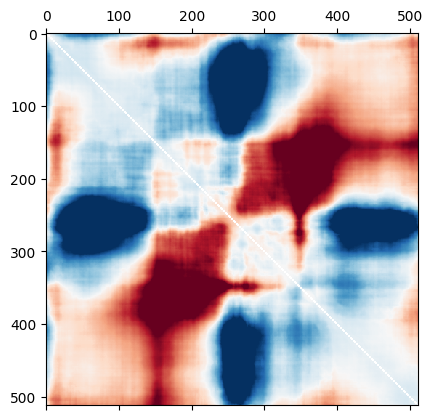

In [25]:
plt.figure(figsize=(8, 8))
matrix = from_upper_triu(ed_pred_model0, matrix_len=512, num_diags=2)
plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
# plt.colorbar()
# plt.savefig("fountain_difference.svg", format='svg')
plt.show()

<Figure size 800x800 with 0 Axes>

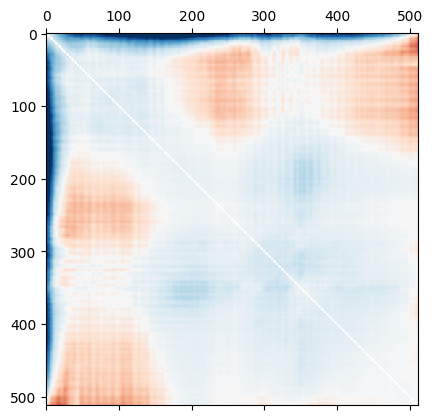

In [26]:
plt.figure(figsize=(8, 8))
matrix = from_upper_triu(ed_pred_model1, matrix_len=512, num_diags=2)
plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
# plt.colorbar()
# plt.savefig("fountain_difference.svg", format='svg')
plt.show()

In [ ]:
plt.figure(figsize=(8, 8))
matrix = from_upper_triu(ed_pred_model2, matrix_len=512, num_diags=2)
plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
# plt.colorbar()
# plt.savefig("fountain_difference.svg", format='svg')
plt.show()

In [ ]:
plt.figure(figsize=(8, 8))
matrix = from_upper_triu(ed_pred_model3, matrix_len=512, num_diags=2)
plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
# plt.colorbar()
# plt.savefig("fountain_difference.svg", format='svg')
plt.show()